# Aerial Human Detection, Tracking, Benchmarking, and Export

**Complete Google Colab notebook for the proposed project**

This notebook covers:

- person-only aerial detection from VisDrone;
- YOLOv9, YOLOv10, and RT-DETR training;
- checkpointing and resume on Google Drive;
- mAP, precision, recall, speed, latency, and VRAM comparison;
- ByteTrack, BoT-SORT, and optional StrongSORT tracking;
- MOTA, MOTP, IDF1, and ID-switch evaluation;
- ONNX, TensorRT FP16, and optional INT8 export;
- image/video inference, CSV/JSON output, Gradio prototype, and final packaging.

> Use only datasets and recordings you are authorized to process.

> Build the final TensorRT engine on the target RTX 3070. TensorRT engines are hardware/software-stack dependent; ONNX and PyTorch weights are the portable artifacts.

## One-month execution plan and Colab budget

| Week | Main result |
|---|---|
| 1 | Environment, data preparation, label audit, smoke tests |
| 2 | YOLOv9/YOLOv10 experiments and resume tests |
| 3 | RT-DETR, tracking, ONNX export, detector comparison |
| 4 | RTX 3070 TensorRT benchmark, MOT metrics, demo, final package |

The default `colab_100cu` profile is conservative because the exact conversion from Colab compute units to GPU hours varies. Always run the `smoke` profile first.

## 1. Install dependencies

In [1]:
# Run once in a fresh Colab GPU runtime.
%pip install -q -U \
  "ultralytics>=8.4.38" \
  "onnx>=1.16" \
  "onnxruntime-gpu>=1.19" \
  "pycocotools>=2.0.8" \
  "motmetrics>=1.4.0" \
  "pandas>=2.2" \
  "pyyaml>=6.0" \
  "gradio>=5.0" \
  "boxmot[yolo]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 19.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 126.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.8/249.8 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Imports, Drive mount, and runtime inspection

In [2]:
from __future__ import annotations

import gc
import hashlib
import json
import math
import os
import platform
import random
import shutil
import subprocess
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Iterable, Sequence

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image
from tqdm.auto import tqdm

from ultralytics import RTDETR, YOLO
from ultralytics.data.utils import check_det_dataset

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Not in Colab; local paths will be used.')

print('Python:', sys.version)
print('Platform:', platform.platform())
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA runtime:', torch.version.cuda)
    subprocess.run(['nvidia-smi'], check=False)
else:
    print('WARNING: select Runtime > Change runtime type > GPU before training.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4
CUDA runtime: 12.8


## 3. Configuration

In [3]:
@dataclass
class ProjectConfig:
    project_name: str = 'aerial_human_detection'
    profile: str = 'colab_100cu'       # smoke | colab_100cu | research
    split_mode: str = 'official'       # official | proposal_60_20_20
    random_seed: int = 42

    # VisDrone YOLO class IDs: 0=pedestrian, 1=people.
    # They are merged into a single target class: person.
    source_person_classes: tuple[int, int] = (0, 1)
    target_class_name: str = 'person'

    confidence_threshold: float = 0.25
    nms_iou_threshold: float = 0.70
    workers: int = 2
    save_period: int = 1
    resume_existing_runs: bool = True
    rebuild_person_dataset: bool = False
    use_symlinks_for_images: bool = True

    export_onnx: bool = True
    export_tensorrt_fp16: bool = False
    export_tensorrt_int8: bool = False
    int8_calibration_fraction: float = 0.20

    run_training: bool = True
    run_validation: bool = True
    run_benchmark: bool = True

CFG = ProjectConfig()

PROFILE_SETTINGS = {
    'smoke': {
        'fraction': 0.05,
        'yolo_epochs': 2,
        'rtdetr_epochs': 1,
        'yolo_imgsz': 640,
        'rtdetr_imgsz': 640,
        'patience': 2,
    },
    'colab_100cu': {
        'fraction': 1.00,
        'yolo_epochs': 25,
        'rtdetr_epochs': 8,
        'yolo_imgsz': 960,
        'rtdetr_imgsz': 640,
        'patience': 10,
    },
    'research': {
        'fraction': 1.00,
        'yolo_epochs': 80,
        'rtdetr_epochs': 35,
        'yolo_imgsz': 1280,
        'rtdetr_imgsz': 960,
        'patience': 20,
    },
}

if CFG.profile not in PROFILE_SETTINGS:
    raise ValueError(f'Unknown profile: {CFG.profile}')
PROFILE = PROFILE_SETTINGS[CFG.profile]

if IN_COLAB:
    DRIVE_ROOT = Path('/content/drive/MyDrive') / CFG.project_name
    LOCAL_ROOT = Path('/content') / CFG.project_name
else:
    DRIVE_ROOT = Path.cwd() / f'{CFG.project_name}_drive'
    LOCAL_ROOT = Path.cwd() / f'{CFG.project_name}_local'

DATASET_ROOT = LOCAL_ROOT / 'datasets' / 'visdrone_person'
RUNS_ROOT = DRIVE_ROOT / 'runs'
ARTIFACTS_ROOT = DRIVE_ROOT / 'artifacts'
EXPORTS_ROOT = DRIVE_ROOT / 'exports'
TRACKING_ROOT = DRIVE_ROOT / 'tracking'
REPORTS_ROOT = DRIVE_ROOT / 'reports'

for d in [LOCAL_ROOT, DATASET_ROOT, RUNS_ROOT, ARTIFACTS_ROOT, EXPORTS_ROOT, TRACKING_ROOT, REPORTS_ROOT]:
    d.mkdir(parents=True, exist_ok=True)

(DRIVE_ROOT / 'project_config.json').write_text(
    json.dumps({'config': asdict(CFG), 'profile_settings': PROFILE}, indent=2),
    encoding='utf-8',
)

print('Local root:', LOCAL_ROOT)
print('Persistent root:', DRIVE_ROOT)
print('Active profile:', CFG.profile, PROFILE)

Local root: /content/aerial_human_detection
Persistent root: /content/drive/MyDrive/aerial_human_detection
Active profile: colab_100cu {'fraction': 1.0, 'yolo_epochs': 25, 'rtdetr_epochs': 8, 'yolo_imgsz': 960, 'rtdetr_imgsz': 640, 'patience': 10}


## 4. Reproducibility helpers

In [4]:
def seed_everything(seed: int) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def clear_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def gpu_peak_memory_mb() -> float:
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.max_memory_allocated() / (1024 ** 2)

seed_everything(CFG.random_seed)
clear_memory()

## 5. Download VisDrone2019-DET

In [5]:
# Ultralytics downloads and converts VisDrone automatically.
visdrone_info = check_det_dataset('VisDrone.yaml', autodownload=True)
for key in ['path', 'train', 'val', 'test', 'names']:
    if key in visdrone_info:
        print(f'{key}: {visdrone_info[key]}')


WARNING ⚠️ Dataset 'VisDrone.yaml' images not found, missing path '/content/datasets/VisDrone/images/val'
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-val.zip to /content/datasets/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 1.0Kfiles/s 1.1s
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-test-dev.zip to /content/datasets/VisDrone/VisDrone2019-DET-test-dev...: 100% ━━━━━━━━━━━━ 3223/3223 690.2files/s 4.7s
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-train.zip to /content/datasets/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 1.8Kfiles/s 7.4s
Converting train: ━━━━━━━━━━━━ 6471 2.4Kit/s 2.8s
Converting val: ━━━━━━━━━━━━ 548 1.4Kit/s 0.3s
Converting test: ━━━━━━━━━━━━ 1610 2.3Kit/s 0.6s
Dataset download success ✅ (18.5s), saved to /content/datasets

path: /content/datasets/VisDrone
train: /content/datasets/VisDrone/images/train
val: /content/datasets/VisDrone/images/val
test: /content/datasets/VisDrone/images/test
names: {0: '

## 6. Create the one-class aerial-person dataset

In [6]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

def expand_image_source(source: Any) -> list[Path]:
    if source is None:
        return []
    if isinstance(source, (list, tuple)):
        result = []
        for item in source:
            result.extend(expand_image_source(item))
        return sorted(set(result))

    path = Path(str(source))
    if path.is_dir():
        return sorted(p for p in path.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
    if path.is_file() and path.suffix.lower() == '.txt':
        images = []
        for line in path.read_text(encoding='utf-8').splitlines():
            line = line.strip()
            if not line:
                continue
            candidate = Path(line)
            if not candidate.is_absolute():
                candidate = path.parent / candidate
            if candidate.suffix.lower() in IMAGE_EXTENSIONS:
                images.append(candidate.resolve())
        return sorted(set(images))
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        return [path.resolve()]
    raise FileNotFoundError(f'Cannot expand image source: {source}')

def image_to_label_path(image_path: Path) -> Path:
    parts = list(image_path.parts)
    try:
        index = len(parts) - 1 - parts[::-1].index('images')
        parts[index] = 'labels'
        return Path(*parts).with_suffix('.txt')
    except ValueError:
        return image_path.with_suffix('.txt')

def stable_destination_name(image_path: Path) -> str:
    digest = hashlib.sha1(str(image_path).encode('utf-8')).hexdigest()[:10]
    return f'{digest}_{image_path.name}'

def link_or_copy(source: Path, destination: Path, use_symlink: bool = True) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists() or destination.is_symlink():
        destination.unlink()
    if use_symlink:
        try:
            destination.symlink_to(source.resolve())
            return
        except OSError:
            pass
    shutil.copy2(source, destination)

def filtered_person_label(source_label: Path, accepted_classes: Sequence[int]) -> tuple[list[str], int]:
    if not source_label.exists():
        return [], 0
    output = []
    for raw in source_label.read_text(encoding='utf-8').splitlines():
        fields = raw.strip().split()
        if len(fields) < 5:
            continue
        try:
            source_class = int(float(fields[0]))
            coords = [float(v) for v in fields[1:5]]
        except ValueError:
            continue
        if source_class not in accepted_classes or not all(np.isfinite(coords)):
            continue
        x, y, w, h = coords
        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
            continue
        output.append('0 ' + ' '.join(f'{v:.8f}' for v in coords))
    return output, len(output)

def deterministic_partition(items: Sequence[Path], seed: int) -> dict[str, list[Path]]:
    shuffled = list(items)
    random.Random(seed).shuffle(shuffled)
    n = len(shuffled)
    n_train = int(0.60 * n)
    n_val = int(0.20 * n)
    return {
        'train': shuffled[:n_train],
        'val': shuffled[n_train:n_train+n_val],
        'test': shuffled[n_train+n_val:],
    }

def build_person_dataset(dataset_info: dict[str, Any], output_root: Path) -> pd.DataFrame:
    manifest_path = output_root / 'manifest.csv'
    data_yaml_path = output_root / 'data.yaml'
    if manifest_path.exists() and data_yaml_path.exists() and not CFG.rebuild_person_dataset:
        print('Using existing person-only dataset:', output_root)
        return pd.read_csv(manifest_path)

    if output_root.exists():
        shutil.rmtree(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    original = {
        'train': expand_image_source(dataset_info.get('train')),
        'val': expand_image_source(dataset_info.get('val')),
        'test': expand_image_source(dataset_info.get('test')),
    }
    print('Original split sizes:', {k: len(v) for k, v in original.items()})

    if CFG.split_mode == 'official':
        target = original
    elif CFG.split_mode == 'proposal_60_20_20':
        target = deterministic_partition(sorted(set(original['train'] + original['val'])), CFG.random_seed)
    else:
        raise ValueError(f'Unsupported split mode: {CFG.split_mode}')

    rows = []
    for split, image_paths in target.items():
        image_dir = output_root / 'images' / split
        label_dir = output_root / 'labels' / split
        image_dir.mkdir(parents=True, exist_ok=True)
        label_dir.mkdir(parents=True, exist_ok=True)

        for source_image in tqdm(image_paths, desc=f'Preparing {split}'):
            source_label = image_to_label_path(source_image)
            destination_name = stable_destination_name(source_image)
            destination_image = image_dir / destination_name
            destination_label = label_dir / Path(destination_name).with_suffix('.txt').name
            lines, box_count = filtered_person_label(source_label, CFG.source_person_classes)
            link_or_copy(source_image, destination_image, CFG.use_symlinks_for_images)
            destination_label.write_text('\n'.join(lines) + ('\n' if lines else ''), encoding='utf-8')
            rows.append({
                'split': split,
                'source_image': str(source_image),
                'source_label': str(source_label),
                'image': str(destination_image),
                'label': str(destination_label),
                'person_boxes': box_count,
                'is_negative': box_count == 0,
            })

    manifest = pd.DataFrame(rows)
    manifest.to_csv(manifest_path, index=False)
    data_yaml = {
        'path': str(output_root),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'names': {0: CFG.target_class_name},
        'nc': 1,
    }
    data_yaml_path.write_text(yaml.safe_dump(data_yaml, sort_keys=False), encoding='utf-8')
    print(manifest.groupby('split').agg(images=('image','count'), person_boxes=('person_boxes','sum'), negative_images=('is_negative','sum')))
    return manifest

manifest = build_person_dataset(visdrone_info, DATASET_ROOT)
DATA_YAML = DATASET_ROOT / 'data.yaml'
print(DATA_YAML.read_text(encoding='utf-8'))

Original split sizes: {'train': 6471, 'val': 548, 'test': 1610}


Preparing train:   0%|          | 0/6471 [00:00<?, ?it/s]

Preparing val:   0%|          | 0/548 [00:00<?, ?it/s]

Preparing test:   0%|          | 0/1610 [00:00<?, ?it/s]

       images  person_boxes  negative_images
split                                       
test     1610         27382              343
train    6471        106396              787
val       548         13969               17
path: /content/aerial_human_detection/datasets/visdrone_person
train: images/train
val: images/val
test: images/test
names:
  0: person
nc: 1



## 7. Validate labels and analyze small-object sizes

In [7]:
def validate_label_file(label_path: Path) -> list[str]:
    errors = []
    for line_number, line in enumerate(label_path.read_text(encoding='utf-8').splitlines(), 1):
        fields = line.strip().split()
        if not fields:
            continue
        if len(fields) != 5:
            errors.append(f'{label_path}:{line_number} expected 5 fields')
            continue
        try:
            class_id = int(float(fields[0]))
            x, y, w, h = map(float, fields[1:])
        except ValueError:
            errors.append(f'{label_path}:{line_number} non-numeric value')
            continue
        if class_id != 0:
            errors.append(f'{label_path}:{line_number} class is not 0')
        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
            errors.append(f'{label_path}:{line_number} invalid box')
    return errors

all_errors = []
for label_path in tqdm(list((DATASET_ROOT/'labels').rglob('*.txt')), desc='Checking labels'):
    all_errors.extend(validate_label_file(label_path))
if all_errors:
    print('\n'.join(all_errors[:20]))
    raise RuntimeError(f'Found {len(all_errors)} label errors')
print('All labels passed.')

split_summary = manifest.groupby('split').agg(
    images=('image','count'),
    positive_images=('is_negative', lambda s: int((~s).sum())),
    negative_images=('is_negative','sum'),
    person_boxes=('person_boxes','sum'),
).reset_index()
display(split_summary)
split_summary.to_csv(REPORTS_ROOT/'dataset_split_summary.csv', index=False)

Checking labels:   0%|          | 0/8629 [00:00<?, ?it/s]

All labels passed.


,split,images,positive_images,negative_images,person_boxes
0,test,1610,1267,343,27382
1,train,6471,5684,787,106396
2,val,548,531,17,13969


Box statistics:   0%|          | 0/2500 [00:00<?, ?it/s]

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
width_px,44977.0,14.982660,12.476727,1.999680,4.999400,7.000320,11.999400,18.000820,28.000000,37.000000,227.999800
height_px,44977.0,27.891069,21.438312,1.999944,8.999748,14.000265,22.000140,34.999808,52.999800,66.000000,338.000250
area_px,44977.0,630.321921,1510.093075,5.999520,48.003360,109.990960,252.998150,615.996500,1380.012645,2224.847664,72669.850950
relative_area,44977.0,0.000437,0.000953,0.000004,0.000041,0.000082,0.000196,0.000452,0.001015,0.001574,0.049435


COCO-small share: 85.26%
Side below 10 px: 40.44%


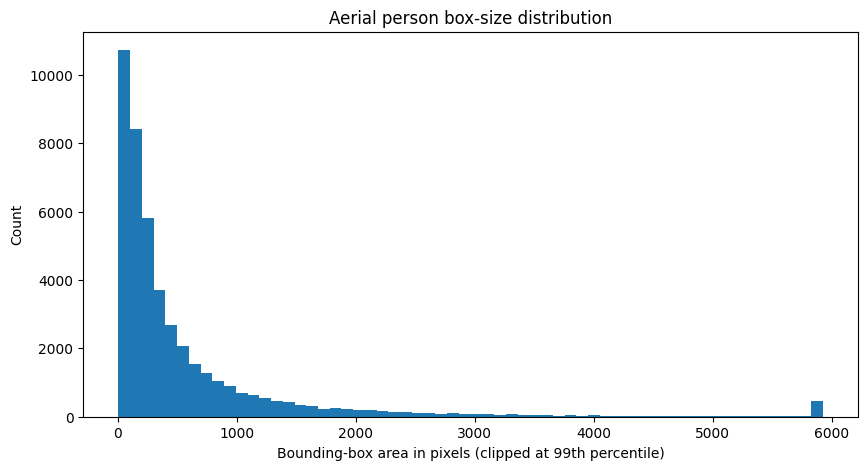

In [8]:
def collect_box_statistics(manifest_df: pd.DataFrame, max_images: int = 2500) -> pd.DataFrame:
    sample_df = manifest_df.sample(max_images, random_state=CFG.random_seed) if len(manifest_df) > max_images else manifest_df
    rows = []
    for record in tqdm(sample_df.itertuples(index=False), total=len(sample_df), desc='Box statistics'):
        with Image.open(record.image) as image:
            image_width, image_height = image.size
        for line in Path(record.label).read_text(encoding='utf-8').splitlines():
            fields = line.split()
            if len(fields) != 5:
                continue
            _, x, y, w, h = map(float, fields)
            width_px = w * image_width
            height_px = h * image_height
            rows.append({
                'split': record.split,
                'width_px': width_px,
                'height_px': height_px,
                'area_px': width_px * height_px,
                'relative_area': w*h,
                'is_coco_small': width_px*height_px < 32*32,
                'has_side_below_10px': min(width_px, height_px) < 10,
            })
    return pd.DataFrame(rows)

box_stats = collect_box_statistics(manifest)
if len(box_stats):
    display(box_stats.describe(percentiles=[.1,.25,.5,.75,.9,.95]).T)
    print('COCO-small share:', f"{100*box_stats['is_coco_small'].mean():.2f}%")
    print('Side below 10 px:', f"{100*box_stats['has_side_below_10px'].mean():.2f}%")
    box_stats.to_csv(REPORTS_ROOT/'box_size_statistics.csv', index=False)
    plt.figure(figsize=(10,5))
    clipped = np.clip(box_stats['area_px'], 0, np.percentile(box_stats['area_px'], 99))
    plt.hist(clipped, bins=60)
    plt.xlabel('Bounding-box area in pixels (clipped at 99th percentile)')
    plt.ylabel('Count')
    plt.title('Aerial person box-size distribution')
    plt.show()

In [9]:
def draw_yolo_labels(image_path: Path, label_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(image_path)
    height, width = image.shape[:2]
    for line in label_path.read_text(encoding='utf-8').splitlines():
        fields = line.split()
        if len(fields) != 5:
            continue
        _, x, y, w, h = map(float, fields)
        x1, y1 = int((x-w/2)*width), int((y-h/2)*height)
        x2, y2 = int((x+w/2)*width), int((y+h/2)*height)
        cv2.rectangle(image, (x1,y1), (x2,y2), 2)
        cv2.putText(image, 'person', (max(0,x1), max(12,y1-4)), cv2.FONT_HERSHEY_SIMPLEX, .45, 1, cv2.LINE_AA)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

positive = manifest[manifest['person_boxes'] > 0]
samples = positive.sample(min(6, len(positive)), random_state=CFG.random_seed)
plt.figure(figsize=(16,10))
for i, row in enumerate(samples.itertuples(index=False), 1):
    plt.subplot(2,3,i)
    plt.imshow(draw_yolo_labels(Path(row.image), Path(row.label)))
    plt.title(f'{row.split}: {row.person_boxes} boxes')
    plt.axis('off')
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 8. Three detector experiments

In [10]:
MODEL_SPECS = [
    {'name':'yolov9t', 'weights':'yolov9t.pt', 'family':'YOLOv9', 'epochs':PROFILE['yolo_epochs'], 'imgsz':PROFILE['yolo_imgsz']},
    {'name':'yolov10n', 'weights':'yolov10n.pt', 'family':'YOLOv10', 'epochs':PROFILE['yolo_epochs'], 'imgsz':PROFILE['yolo_imgsz']},
    {'name':'rtdetr_l', 'weights':'rtdetr-l.pt', 'family':'RT-DETR', 'epochs':PROFILE['rtdetr_epochs'], 'imgsz':PROFILE['rtdetr_imgsz']},
]
display(pd.DataFrame(MODEL_SPECS))

,name,weights,family,epochs,imgsz
0,yolov9t,yolov9t.pt,YOLOv9,25,960
1,yolov10n,yolov10n.pt,YOLOv10,25,960
2,rtdetr_l,rtdetr-l.pt,RT-DETR,8,640


## 9. Train with Drive checkpoints and automatic resume

In [11]:
def load_detector(weights: str | Path):
    weights_text = str(weights)
    return RTDETR(weights_text) if 'rtdetr' in Path(weights_text).name.lower() else YOLO(weights_text)

def run_directory(model_name: str) -> Path:
    return RUNS_ROOT / model_name

def train_one_model(spec: dict[str, Any]) -> dict[str, Any]:
    name = spec['name']
    run_dir = run_directory(name)
    last_pt = run_dir/'weights'/'last.pt'
    best_pt = run_dir/'weights'/'best.pt'
    clear_memory()
    seed_everything(CFG.random_seed)

    try:
        if CFG.resume_existing_runs and last_pt.exists():
            print(f'Resuming {name} from {last_pt}')
            model = load_detector(last_pt)
            model.train(resume=True)
        else:
            print(f'Starting {name} from {spec["weights"]}')
            model = load_detector(spec['weights'])
            model.train(
                data=str(DATA_YAML),
                epochs=int(spec['epochs']),
                imgsz=int(spec['imgsz']),
                batch=-1,
                device=0 if torch.cuda.is_available() else 'cpu',
                workers=CFG.workers,
                project=str(RUNS_ROOT),
                name=name,
                exist_ok=True,
                pretrained=True,
                optimizer='AdamW',
                cos_lr=True,
                warmup_epochs=3.0,
                patience=PROFILE['patience'],
                save=True,
                save_period=CFG.save_period,
                seed=CFG.random_seed,
                deterministic=True,
                amp=True,
                plots=True,
                fraction=PROFILE['fraction'],
                close_mosaic=min(10, max(0, int(spec['epochs'])//3)),
                mosaic=1.0,
                mixup=0.05,
                degrees=5.0,
                translate=0.10,
                scale=0.50,
                shear=2.0,
                fliplr=0.50,
                hsv_h=0.015,
                hsv_s=0.50,
                hsv_v=0.40,
                cache=False,
                verbose=True,
            )
        status, error = 'completed', None
    except Exception as exc:
        status, error = 'failed', repr(exc)
        print(f'{name} failed: {error}')
    finally:
        clear_memory()

    record = {
        **spec,
        'status': status,
        'error': error,
        'run_dir': str(run_dir),
        'last_checkpoint': str(last_pt) if last_pt.exists() else None,
        'best_checkpoint': str(best_pt) if best_pt.exists() else None,
    }
    (REPORTS_ROOT/f'{name}_training_status.json').write_text(json.dumps(record, indent=2), encoding='utf-8')
    return record

training_registry = []
if CFG.run_training:
    for spec in MODEL_SPECS:
        training_registry.append(train_one_model(spec))
else:
    for spec in MODEL_SPECS:
        best_pt = run_directory(spec['name'])/'weights'/'best.pt'
        last_pt = run_directory(spec['name'])/'weights'/'last.pt'
        training_registry.append({**spec, 'status':'existing' if best_pt.exists() else 'not_run', 'error':None,
                                  'run_dir':str(run_directory(spec['name'])),
                                  'best_checkpoint':str(best_pt) if best_pt.exists() else None,
                                  'last_checkpoint':str(last_pt) if last_pt.exists() else None})
training_registry_df = pd.DataFrame(training_registry)
display(training_registry_df)
training_registry_df.to_csv(REPORTS_ROOT/'training_registry.csv', index=False)

Resuming yolov9t from /content/drive/MyDrive/aerial_human_detection/runs/yolov9t/weights/last.pt
WARNING ⚠️ model '/content/drive/MyDrive/aerial_human_detection/runs/yolov9t/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/100      3.42G     0.6057      2.665     0.4745         20        640: 100% ━━━━━━━━━━━━ 1/1 3.0it/s 0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 9.0it/s 0.1s
                   all          4         17      0.255     0.0833      0.076     0.0494


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/100      3.47G      1.112      1.937     0.6595         26        640: 100% ━━━━━━━━━━━━ 1/1 2.8it/s 0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 8.9it/s 0.1s
                   all          4         17      0.255     0.0833      0.076     0.0494


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
    100/100      3.66G     0.3496      2.236     0.2375         13        640: 100% ━━━━━━━━━━━━ 1/1 2.7it/s 0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 10.4it/s 0.1s
                   all          4         17      0.208     0.0667     0.0405     0.0252


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



100 epochs completed in 0.052 hours.
Optimizer stripped from /content/runs/detect/train-3/weights/last.pt, 66.5MB
Optimizer stripped from /content/runs/detect/train-3/weights/best.pt, 66.5MB

Validating /content/runs/detect/train-3/weights/best.pt...
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
rt-detr-l summary: 315 layers, 32,148,140 parameters, 0 gradients, 105.7 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 13.0it/s 0.1s
                   all          4         17      0.289     0.0833     0.0949     0.0528
                person          3         10      0.735        0.5      0.564      0.313
                   dog          1          1          0          0          0          0
                 horse          1          2          0          0          0          0
              elephant          1          2          0          0          0          0
            

,name,weights,family,epochs,imgsz,status,error,run_dir,last_checkpoint,best_checkpoint
0,yolov9t,yolov9t.pt,YOLOv9,25,960,completed,None,/content/drive/MyDrive/aerial_human_detection/...,/content/drive/MyDrive/aerial_human_detection/...,/content/drive/MyDrive/aerial_human_detection/...
1,yolov10n,yolov10n.pt,YOLOv10,25,960,completed,None,/content/drive/MyDrive/aerial_human_detection/...,/content/drive/MyDrive/aerial_human_detection/...,/content/drive/MyDrive/aerial_human_detection/...
2,rtdetr_l,rtdetr-l.pt,RT-DETR,8,640,completed,None,/content/drive/MyDrive/aerial_human_detection/...,/content/drive/MyDrive/aerial_human_detection/...,/content/drive/MyDrive/aerial_human_detection/...


## 10. Training-summary table

In [12]:
def first_matching_column(columns: Iterable[str], candidates: Sequence[str]) -> str | None:
    normalized = {c.lower().replace(' ',''): c for c in columns}
    for candidate in candidates:
        key = candidate.lower().replace(' ','')
        if key in normalized:
            return normalized[key]
    return None

def summarize_training_run(spec: dict[str, Any]) -> dict[str, Any] | None:
    results_csv = run_directory(spec['name'])/'results.csv'
    if not results_csv.exists():
        return None
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    map_col = first_matching_column(df.columns, ['metrics/mAP50-95(B)','metrics/mAP50-95','metrics/mAP_0.5:0.95'])
    map50_col = first_matching_column(df.columns, ['metrics/mAP50(B)','metrics/mAP50'])
    precision_col = first_matching_column(df.columns, ['metrics/precision(B)','metrics/precision'])
    recall_col = first_matching_column(df.columns, ['metrics/recall(B)','metrics/recall'])
    best_index = int(df[map_col].astype(float).idxmax()) if map_col else len(df)-1
    row = df.loc[best_index]
    return {
        'model':spec['name'], 'family':spec['family'], 'best_epoch':int(row.get('epoch',best_index)),
        'map50_95':float(row[map_col]) if map_col else np.nan,
        'map50':float(row[map50_col]) if map50_col else np.nan,
        'precision':float(row[precision_col]) if precision_col else np.nan,
        'recall':float(row[recall_col]) if recall_col else np.nan,
        'results_csv':str(results_csv),
        'best_checkpoint':str(run_directory(spec['name'])/'weights'/'best.pt'),
    }

training_summaries = [s for spec in MODEL_SPECS if (s := summarize_training_run(spec)) is not None]
training_summary_df = pd.DataFrame(training_summaries)
if len(training_summary_df):
    training_summary_df = training_summary_df.sort_values('map50_95', ascending=False)
    display(training_summary_df)
    training_summary_df.to_csv(REPORTS_ROOT/'training_summary.csv', index=False)
else:
    print('No completed training results yet.')

,model,family,best_epoch,map50_95,map50,precision,recall,results_csv,best_checkpoint
2,rtdetr_l,RT-DETR,1,0.10256,0.26691,0.45070,0.27718,/content/drive/MyDrive/aerial_human_detection/...,/content/drive/MyDrive/aerial_human_detection/...
0,yolov9t,YOLOv9,1,0.00000,0.00000,0.00001,0.00014,/content/drive/MyDrive/aerial_human_detection/...,/content/drive/MyDrive/aerial_human_detection/...
1,yolov10n,YOLOv10,1,0.00000,0.00000,0.00000,0.00000,/content/drive/MyDrive/aerial_human_detection/...,/content/drive/MyDrive/aerial_human_detection/...


## 11. Independent validation or test evaluation

In [13]:
def metric_float(value: Any) -> float:
    try:
        return float(value.item()) if hasattr(value, 'item') else float(value)
    except Exception:
        return float('nan')

def validate_one_model(spec: dict[str, Any]) -> dict[str, Any] | None:
    checkpoint = run_directory(spec['name'])/'weights'/'best.pt'
    if not checkpoint.exists():
        print('Missing checkpoint:', checkpoint)
        return None
    clear_memory()
    model = load_detector(checkpoint)
    try:
        metrics = model.val(data=str(DATA_YAML), split='test', imgsz=int(spec['imgsz']), batch=1,
                            device=0 if torch.cuda.is_available() else 'cpu', conf=0.001,
                            iou=CFG.nms_iou_threshold, plots=True, save_json=False,
                            project=str(REPORTS_ROOT/'validation'), name=spec['name'], exist_ok=True, verbose=True)
        used_split = 'test'
    except Exception as exc:
        print('Test split failed; falling back to val:', exc)
        metrics = model.val(data=str(DATA_YAML), split='val', imgsz=int(spec['imgsz']), batch=1,
                            device=0 if torch.cuda.is_available() else 'cpu', conf=0.001,
                            iou=CFG.nms_iou_threshold, plots=True, save_json=False,
                            project=str(REPORTS_ROOT/'validation'), name=f"{spec['name']}_val", exist_ok=True, verbose=True)
        used_split = 'val'
    record = {
        'model':spec['name'], 'family':spec['family'], 'split':used_split, 'imgsz':spec['imgsz'],
        'precision':metric_float(metrics.box.mp), 'recall':metric_float(metrics.box.mr),
        'map50':metric_float(metrics.box.map50), 'map50_95':metric_float(metrics.box.map),
        'fitness':metric_float(getattr(metrics,'fitness',np.nan)),
        'preprocess_ms':metric_float(metrics.speed.get('preprocess',np.nan)),
        'inference_ms':metric_float(metrics.speed.get('inference',np.nan)),
        'postprocess_ms':metric_float(metrics.speed.get('postprocess',np.nan)),
        'checkpoint':str(checkpoint),
    }
    clear_memory()
    return record

validation_records = []
if CFG.run_validation:
    for spec in MODEL_SPECS:
        result = validate_one_model(spec)
        if result is not None:
            validation_records.append(result)
validation_df = pd.DataFrame(validation_records)
if len(validation_df):
    validation_df = validation_df.sort_values('map50_95', ascending=False)
    display(validation_df)
    validation_df.to_csv(REPORTS_ROOT/'detector_validation_metrics.csv', index=False)

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLOv9t summary (fused): 197 layers, 1,970,979 parameters, 0 gradients, 7.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2531.2±966.3 MB/s, size: 241.6 KB)
val: Scanning /content/aerial_human_detection/datasets/visdrone_person/labels/test... 1610 images, 343 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 1.5Kit/s 1.1s
val: New cache created: /content/aerial_human_detection/datasets/visdrone_person/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1610/1610 38.0it/s 42.3s
                   all       1610      27382          0          0          0          0
Speed: 1.1ms preprocess, 19.2ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/drive/MyDrive/aerial_human_detection/reports/validation/yolov9t
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)

,model,family,split,imgsz,precision,recall,map50,map50_95,fitness,preprocess_ms,inference_ms,postprocess_ms,checkpoint
2,rtdetr_l,RT-DETR,test,640,0.279904,0.133993,0.097395,0.039842,0.039842,0.962481,41.838897,0.459181,/content/drive/MyDrive/aerial_human_detection/...
0,yolov9t,YOLOv9,test,960,0.000000,0.000000,0.000000,0.000000,0.000000,1.126290,19.224288,1.366167,/content/drive/MyDrive/aerial_human_detection/...
1,yolov10n,YOLOv10,test,960,0.000000,0.000000,0.000000,0.000000,0.000000,1.182644,10.107998,0.289762,/content/drive/MyDrive/aerial_human_detection/...


## 12. Select the best detector

In [14]:
def select_best_checkpoint(validation_table: pd.DataFrame, training_table: pd.DataFrame) -> tuple[Path,str,int]:
    if len(validation_table):
        row = validation_table.sort_values(['map50_95','map50','recall'], ascending=False).iloc[0]
        return Path(row['checkpoint']), str(row['model']), int(row['imgsz'])
    if len(training_table):
        row = training_table.sort_values('map50_95', ascending=False).iloc[0]
        name = str(row['model'])
        spec = next(x for x in MODEL_SPECS if x['name']==name)
        return Path(row['best_checkpoint']), name, int(spec['imgsz'])
    existing = [(run_directory(s['name'])/'weights'/'best.pt', s) for s in MODEL_SPECS if (run_directory(s['name'])/'weights'/'best.pt').exists()]
    if not existing:
        raise FileNotFoundError('No best.pt checkpoint exists.')
    checkpoint, spec = existing[0]
    return checkpoint, spec['name'], int(spec['imgsz'])

BEST_MODEL_PATH, BEST_MODEL_NAME, BEST_IMGSZ = select_best_checkpoint(
    validation_df if 'validation_df' in globals() else pd.DataFrame(),
    training_summary_df if 'training_summary_df' in globals() else pd.DataFrame(),
)
print('Best model:', BEST_MODEL_NAME)
print('Checkpoint:', BEST_MODEL_PATH)
print('Image size:', BEST_IMGSZ)
BEST_MODEL = load_detector(BEST_MODEL_PATH)

Best model: rtdetr_l
Checkpoint: /content/drive/MyDrive/aerial_human_detection/runs/rtdetr_l/weights/best.pt
Image size: 640


## 13. Visual inspection on held-out images

In [15]:
def show_predictions(model, image_paths: Sequence[Path], imgsz: int, conf: float, columns: int = 2) -> None:
    results = model.predict([str(p) for p in image_paths], imgsz=imgsz, conf=conf,
                            iou=CFG.nms_iou_threshold, device=0 if torch.cuda.is_available() else 'cpu', verbose=False)
    rows = math.ceil(len(results)/columns)
    plt.figure(figsize=(8*columns,6*rows))
    for i, result in enumerate(results,1):
        plotted = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        plt.subplot(rows,columns,i)
        plt.imshow(plotted)
        plt.title(Path(result.path).name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

test_candidates = [Path(p) for p in manifest.loc[manifest['split']=='test','image'].tolist()]
if not test_candidates:
    test_candidates = [Path(p) for p in manifest.loc[manifest['split']=='val','image'].tolist()]
sample_images = random.Random(CFG.random_seed).sample(test_candidates, min(6,len(test_candidates)))
show_predictions(BEST_MODEL, sample_images, BEST_IMGSZ, CFG.confidence_threshold)

Output hidden; open in https://colab.research.google.com to view.

## 14. End-to-end FPS, latency, and VRAM benchmark

yolov9t:   0%|          | 0/100 [00:00<?, ?it/s]

yolov10n:   0%|          | 0/100 [00:00<?, ?it/s]

rtdetr_l:   0%|          | 0/100 [00:00<?, ?it/s]

,model,checkpoint,imgsz,images,elapsed_seconds,end_to_end_ms_per_image,end_to_end_fps,preprocess_ms,inference_ms,postprocess_ms,peak_gpu_memory_mb,gpu_name
1,yolov10n,/content/drive/MyDrive/aerial_human_detection/...,960,100,1.970094,19.700941,50.758998,3.085463,9.643136,0.493478,224.221191,NVIDIA L4
0,yolov9t,/content/drive/MyDrive/aerial_human_detection/...,960,100,3.063043,30.630431,32.647272,3.174857,19.108121,1.593051,227.139648,NVIDIA L4
2,rtdetr_l,/content/drive/MyDrive/aerial_human_detection/...,640,100,5.283263,52.832628,18.927697,2.857186,42.186333,0.695503,393.519043,NVIDIA L4


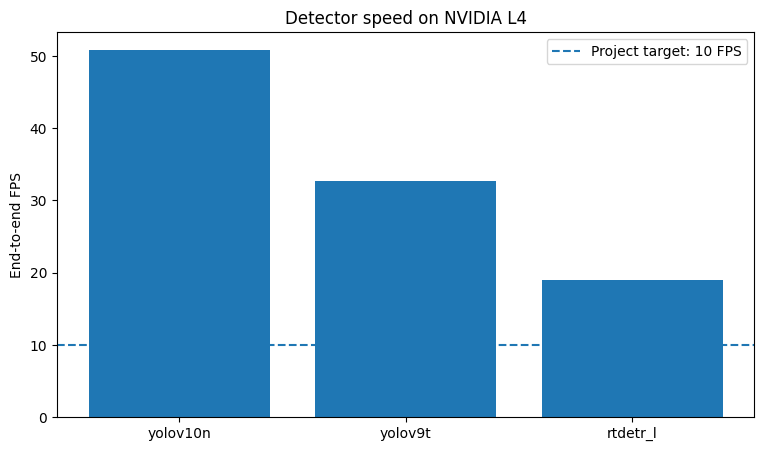

In [16]:
def benchmark_detector(checkpoint: Path, image_paths: Sequence[Path], imgsz: int, maximum_images: int = 100) -> dict[str,Any]:
    clear_memory()
    model = load_detector(checkpoint)
    selected = list(image_paths)[:maximum_images]
    if not selected:
        raise ValueError('No benchmark images')
    for _ in range(10):
        model.predict(str(selected[0]), imgsz=imgsz, conf=CFG.confidence_threshold,
                      device=0 if torch.cuda.is_available() else 'cpu', verbose=False)
    if torch.cuda.is_available():
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()
    speeds = []
    for image_path in tqdm(selected, desc=checkpoint.parent.parent.name):
        result = model.predict(str(image_path), imgsz=imgsz, conf=CFG.confidence_threshold,
                               iou=CFG.nms_iou_threshold, device=0 if torch.cuda.is_available() else 'cpu', verbose=False)[0]
        speeds.append(result.speed)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter()-start
    record = {
        'model':checkpoint.parent.parent.name, 'checkpoint':str(checkpoint), 'imgsz':imgsz,
        'images':len(selected), 'elapsed_seconds':elapsed,
        'end_to_end_ms_per_image':1000*elapsed/len(selected), 'end_to_end_fps':len(selected)/elapsed,
        'preprocess_ms':float(np.mean([s.get('preprocess',np.nan) for s in speeds])),
        'inference_ms':float(np.mean([s.get('inference',np.nan) for s in speeds])),
        'postprocess_ms':float(np.mean([s.get('postprocess',np.nan) for s in speeds])),
        'peak_gpu_memory_mb':gpu_peak_memory_mb(),
        'gpu_name':torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
    }
    clear_memory()
    return record

benchmark_records=[]
if CFG.run_benchmark:
    for spec in MODEL_SPECS:
        checkpoint=run_directory(spec['name'])/'weights'/'best.pt'
        if checkpoint.exists():
            benchmark_records.append(benchmark_detector(checkpoint,test_candidates,int(spec['imgsz'])))
benchmark_df=pd.DataFrame(benchmark_records)
if len(benchmark_df):
    benchmark_df=benchmark_df.sort_values('end_to_end_fps',ascending=False)
    display(benchmark_df)
    benchmark_df.to_csv(REPORTS_ROOT/'pytorch_speed_benchmark.csv',index=False)
    plt.figure(figsize=(9,5))
    plt.bar(benchmark_df['model'],benchmark_df['end_to_end_fps'])
    plt.axhline(10,linestyle='--',label='Project target: 10 FPS')
    plt.ylabel('End-to-end FPS')
    plt.title(f"Detector speed on {benchmark_df.iloc[0]['gpu_name']}")
    plt.legend(); plt.show()

## 15. Optional final fine-tuning of only the winning detector

In [17]:
RUN_FINAL_FINE_TUNING = False
FINAL_EPOCHS = 40
FINAL_IMGSZ = 1280
if RUN_FINAL_FINE_TUNING:
    final_name=f'{BEST_MODEL_NAME}_final_{FINAL_IMGSZ}'
    final_model=load_detector(BEST_MODEL_PATH)
    final_model.train(data=str(DATA_YAML),epochs=FINAL_EPOCHS,imgsz=FINAL_IMGSZ,batch=-1,
                      device=0 if torch.cuda.is_available() else 'cpu',workers=CFG.workers,
                      project=str(RUNS_ROOT),name=final_name,exist_ok=True,pretrained=True,
                      optimizer='AdamW',cos_lr=True,warmup_epochs=3.0,patience=15,save_period=1,
                      seed=CFG.random_seed,deterministic=True,amp=True,plots=True,close_mosaic=10,
                      mosaic=1.0,mixup=0.05,degrees=5.0,translate=.10,scale=.50,fliplr=.50,
                      hsv_h=.015,hsv_s=.50,hsv_v=.40)
    BEST_MODEL_PATH=RUNS_ROOT/final_name/'weights'/'best.pt'
    BEST_MODEL_NAME=final_name
    BEST_IMGSZ=FINAL_IMGSZ
    BEST_MODEL=load_detector(BEST_MODEL_PATH)

## 16. Export PyTorch, ONNX, TensorRT FP16, and optional INT8

In [18]:
def sha256_file(path: Path, block_size: int = 1024*1024) -> str:
    digest=hashlib.sha256()
    with path.open('rb') as f:
        while chunk:=f.read(block_size):
            digest.update(chunk)
    return digest.hexdigest()

def export_best_model(model_path: Path, model_name: str, imgsz: int) -> list[dict[str,Any]]:
    export_dir=EXPORTS_ROOT/model_name
    export_dir.mkdir(parents=True,exist_ok=True)
    model=load_detector(model_path)
    records=[]
    pt_copy=export_dir/f'{model_name}_best.pt'
    shutil.copy2(model_path,pt_copy)
    records.append({'format':'pytorch','precision':'FP32/mixed','path':str(pt_copy),'sha256':sha256_file(pt_copy)})

    if CFG.export_onnx:
        result=model.export(format='onnx',imgsz=imgsz,opset=17,simplify=True,dynamic=False,batch=1,
                            device=0 if torch.cuda.is_available() else 'cpu')
        source=Path(str(result)); destination=export_dir/f'{model_name}_{imgsz}.onnx'
        if source.resolve()!=destination.resolve(): shutil.copy2(source,destination)
        records.append({'format':'onnx','precision':'FP32','path':str(destination),'sha256':sha256_file(destination)})

    if CFG.export_tensorrt_fp16:
        if not torch.cuda.is_available(): raise RuntimeError('TensorRT requires NVIDIA GPU')
        result=model.export(format='engine',imgsz=imgsz,half=True,int8=False,dynamic=False,batch=1,workspace=4,device=0)
        source=Path(str(result)); destination=export_dir/f'{model_name}_{imgsz}_fp16.engine'
        if source.resolve()!=destination.resolve(): shutil.copy2(source,destination)
        records.append({'format':'tensorrt','precision':'FP16','path':str(destination),'sha256':sha256_file(destination),
                        'built_on_gpu':torch.cuda.get_device_name(0)})

    if CFG.export_tensorrt_int8:
        if not torch.cuda.is_available(): raise RuntimeError('TensorRT requires NVIDIA GPU')
        result=model.export(format='engine',imgsz=imgsz,half=False,int8=True,data=str(DATA_YAML),
                            fraction=CFG.int8_calibration_fraction,dynamic=False,batch=1,workspace=4,device=0)
        source=Path(str(result)); destination=export_dir/f'{model_name}_{imgsz}_int8.engine'
        if source.resolve()!=destination.resolve(): shutil.copy2(source,destination)
        records.append({'format':'tensorrt','precision':'INT8','path':str(destination),'sha256':sha256_file(destination),
                        'built_on_gpu':torch.cuda.get_device_name(0),'calibration_fraction':CFG.int8_calibration_fraction})

    (export_dir/'export_manifest.json').write_text(json.dumps(records,indent=2),encoding='utf-8')
    return records

export_records=export_best_model(BEST_MODEL_PATH,BEST_MODEL_NAME,BEST_IMGSZ)
display(pd.DataFrame(export_records))

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
rt-detr-l summary: 315 layers, 31,985,795 parameters, 0 gradients, 105.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/aerial_human_detection/runs/rtdetr_l/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (63.1 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 214ms
Prepared 2 packages in 29ms
Installed 2 packages in 7ms
 + colorama==0.4.6
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 17...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/jit_utils.py:308: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at /pytorch/torch/csrc/jit/passes/onnx/constant_fold.cpp:178.)
  _C._jit_pass_onnx_node_shape_type_inference(node, params_dict, opset_version)
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:714: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice

ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 27.6s, saved as '/content/drive/MyDrive/aerial_human_detection/runs/rtdetr_l/weights/best.onnx' (125.4 MB)

Export complete (28.0s)
Results saved to /content/drive/MyDrive/aerial_human_detection/runs/rtdetr_l/weights/best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/aerial_human_detection/runs/rtdetr_l/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/aerial_human_detection/runs/rtdetr_l/weights/best.onnx imgsz=640 data=/content/aerial_human_detection/datasets/visdrone_person/data.yaml  
Visualize:       https://netron.app


,format,precision,path,sha256
0,pytorch,FP32/mixed,/content/drive/MyDrive/aerial_human_detection/...,4476c4e5201968ce13b07c9f939ce250121924dbee19a4...
1,onnx,FP32,/content/drive/MyDrive/aerial_human_detection/...,c3e5e7c3e0102c2b5fa1c5ace87e19fe1b96179e63f3e5...


## 17. Verify ONNX inference

In [19]:
onnx_paths=[Path(x['path']) for x in export_records if x['format']=='onnx']
if onnx_paths:
    ONNX_MODEL_PATH=onnx_paths[0]
    onnx_model=YOLO(str(ONNX_MODEL_PATH),task='detect')
    onnx_results=onnx_model.predict([str(p) for p in sample_images[:2]],imgsz=BEST_IMGSZ,
                                    conf=CFG.confidence_threshold,iou=CFG.nms_iou_threshold,
                                    device=0 if torch.cuda.is_available() else 'cpu',verbose=False)
    print('ONNX inference succeeded:',ONNX_MODEL_PATH)
    for result in onnx_results:
        print(Path(result.path).name,'detections:',len(result.boxes))

Loading /content/drive/MyDrive/aerial_human_detection/exports/rtdetr_l/rtdetr_l_640.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.28.0 with CUDAExecutionProvider


RuntimeError: Error when binding input: There's no data transfer registered for copying tensors from Device:[DeviceType:1 MemoryType:0 VendorId:4318 DeviceId:0 Alignment:0] to Device:[DeviceType:0 MemoryType:0 VendorId:0 DeviceId:0 Alignment:0]

## 18. Choose or upload a tracking video

In [ ]:
VIDEO_PATH: Path | None = None

def upload_video_to_colab() -> Path:
    if not IN_COLAB:
        raise RuntimeError('Set VIDEO_PATH manually outside Colab')
    from google.colab import files
    uploaded=files.upload()
    if not uploaded:
        raise RuntimeError('No video uploaded')
    filename=next(iter(uploaded))
    destination=LOCAL_ROOT/'input_videos'/filename
    destination.parent.mkdir(parents=True,exist_ok=True)
    destination.write_bytes(uploaded[filename])
    return destination

# VIDEO_PATH = upload_video_to_colab()
# VIDEO_PATH = Path('/content/drive/MyDrive/aerial_human_detection/input/example.mp4')
print('VIDEO_PATH:',VIDEO_PATH)

## 19. ByteTrack and BoT-SORT with annotated video, CSV, and JSON

In [ ]:
def track_video_ultralytics(model_path: Path, source_video: Path, tracker_yaml: str,
                            output_directory: Path, imgsz: int, conf: float, iou: float,
                            trail_length: int = 30) -> dict[str,Path]:
    if not source_video.exists():
        raise FileNotFoundError(source_video)
    output_directory.mkdir(parents=True,exist_ok=True)
    tracker_name=Path(tracker_yaml).stem
    output_video=output_directory/f'{source_video.stem}_{tracker_name}.mp4'
    output_csv=output_directory/f'{source_video.stem}_{tracker_name}.csv'
    output_json=output_directory/f'{source_video.stem}_{tracker_name}.json'

    model=load_detector(model_path)
    capture=cv2.VideoCapture(str(source_video))
    if not capture.isOpened(): raise RuntimeError(f'Could not open {source_video}')
    fps=capture.get(cv2.CAP_PROP_FPS) or 25.0
    width=int(capture.get(cv2.CAP_PROP_FRAME_WIDTH)); height=int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames=int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    writer=cv2.VideoWriter(str(output_video),cv2.VideoWriter_fourcc(*'mp4v'),fps,(width,height))

    history={}; rows=[]; frame_index=0; started=time.perf_counter()
    progress=tqdm(total=total_frames if total_frames>0 else None,desc=tracker_name)
    while True:
        ok,frame=capture.read()
        if not ok: break
        frame_index+=1
        result=model.track(source=frame,persist=True,tracker=tracker_yaml,imgsz=imgsz,conf=conf,iou=iou,
                           classes=[0],device=0 if torch.cuda.is_available() else 'cpu',verbose=False)[0]
        annotated=result.plot(); boxes=result.boxes
        if boxes is not None and boxes.id is not None:
            ids=boxes.id.int().cpu().tolist(); xyxy=boxes.xyxy.cpu().numpy(); scores=boxes.conf.cpu().numpy()
            for track_id,box,score in zip(ids,xyxy,scores):
                x1,y1,x2,y2=map(float,box.tolist())
                center=(int((x1+x2)/2),int((y1+y2)/2))
                points=history.setdefault(int(track_id),[]); points.append(center)
                if len(points)>trail_length: points.pop(0)
                if len(points)>=2:
                    cv2.polylines(annotated,[np.array(points,dtype=np.int32).reshape((-1,1,2))],False,thickness=2)
                rows.append({'frame':frame_index,'track_id':int(track_id),'x1':x1,'y1':y1,'x2':x2,'y2':y2,
                             'confidence':float(score),'class_id':0,'class_name':CFG.target_class_name})
        pipeline_fps=frame_index/max(time.perf_counter()-started,1e-9)
        cv2.putText(annotated,f'Pipeline FPS: {pipeline_fps:.2f}',(20,40),cv2.FONT_HERSHEY_SIMPLEX,1.0,2,cv2.LINE_AA)
        writer.write(annotated); progress.update(1)
    progress.close(); capture.release(); writer.release()
    pd.DataFrame(rows).to_csv(output_csv,index=False)
    output_json.write_text(json.dumps(rows,indent=2),encoding='utf-8')
    return {'video':output_video,'csv':output_csv,'json':output_json}

tracking_outputs={}
if VIDEO_PATH is not None:
    tracking_outputs['bytetrack']=track_video_ultralytics(BEST_MODEL_PATH,VIDEO_PATH,'bytetrack.yaml',
        TRACKING_ROOT/'bytetrack',BEST_IMGSZ,CFG.confidence_threshold,CFG.nms_iou_threshold)
    tracking_outputs['botsort']=track_video_ultralytics(BEST_MODEL_PATH,VIDEO_PATH,'botsort.yaml',
        TRACKING_ROOT/'botsort',BEST_IMGSZ,CFG.confidence_threshold,CFG.nms_iou_threshold)
    print(json.dumps({k:{a:str(b) for a,b in v.items()} for k,v in tracking_outputs.items()},indent=2))
else:
    print('Set VIDEO_PATH and rerun this cell.')

## 20. Optional StrongSORT through BoxMOT

In [ ]:
def run_strongsort_boxmot(model_path: Path, source_video: Path, output_directory: Path) -> subprocess.CompletedProcess:
    if not source_video.exists(): raise FileNotFoundError(source_video)
    output_directory.mkdir(parents=True,exist_ok=True)
    command=['boxmot','track','--detector',str(model_path),'--reid','osnet_x0_25_msmt17','--tracker','strongsort',
             '--source',str(source_video),'--classes','0','--conf',str(CFG.confidence_threshold),
             '--device','0' if torch.cuda.is_available() else 'cpu','--project',str(output_directory),
             '--name','strongsort','--exist-ok','--save']
    if torch.cuda.is_available(): command.append('--half')
    print('Running:',' '.join(command))
    return subprocess.run(command,check=True)

RUN_STRONGSORT=False
if RUN_STRONGSORT:
    if VIDEO_PATH is None: raise ValueError('Set VIDEO_PATH first')
    result=run_strongsort_boxmot(BEST_MODEL_PATH,VIDEO_PATH,TRACKING_ROOT/'strongsort')
    print('StrongSORT return code:',result.returncode)

## 21. MOTChallenge metrics: MOTA, MOTP, IDF1, ID switches

In [ ]:
import motmetrics as mm

def tracking_csv_to_motchallenge(tracking_csv: Path, output_txt: Path) -> Path:
    df=pd.read_csv(tracking_csv)
    required={'frame','track_id','x1','y1','x2','y2','confidence'}
    missing=required-set(df.columns)
    if missing: raise ValueError(f'Missing columns: {sorted(missing)}')
    mot=pd.DataFrame({'frame':df['frame'].astype(int),'id':df['track_id'].astype(int),'x':df['x1'],'y':df['y1'],
                      'w':df['x2']-df['x1'],'h':df['y2']-df['y1'],'conf':df['confidence'],
                      'x3d':-1,'y3d':-1,'z3d':-1})
    output_txt.parent.mkdir(parents=True,exist_ok=True)
    mot.to_csv(output_txt,header=False,index=False)
    return output_txt

def evaluate_motchallenge(ground_truth_txt: Path, prediction_txt: Path, iou_threshold: float=.50) -> pd.DataFrame:
    gt=mm.io.loadtxt(str(ground_truth_txt),fmt='mot15-2D',min_confidence=1)
    prediction=mm.io.loadtxt(str(prediction_txt),fmt='mot15-2D')
    accumulator=mm.utils.compare_to_groundtruth(gt,prediction,dist='iou',distth=iou_threshold)
    metrics=['num_frames','mota','motp','idf1','idp','idr','precision','recall','num_switches','num_false_positives','num_misses']
    return mm.metrics.create().compute(accumulator,metrics=metrics,name='aerial_person_tracking')

# Example:
# GT_MOT_PATH=Path('/content/drive/MyDrive/.../gt.txt')
# PRED_MOT_PATH=tracking_csv_to_motchallenge(tracking_outputs['bytetrack']['csv'],REPORTS_ROOT/'bytetrack_mot.txt')
# mot_summary=evaluate_motchallenge(GT_MOT_PATH,PRED_MOT_PATH)
# display(mot_summary)
# mot_summary.to_csv(REPORTS_ROOT/'bytetrack_mot_metrics.csv')

## 22. Confidence-threshold sweep

In [ ]:
def confidence_sweep(model_path: Path, thresholds=(.05,.10,.20,.25,.35,.50)) -> pd.DataFrame:
    model=load_detector(model_path); rows=[]
    for threshold in thresholds:
        metrics=model.val(data=str(DATA_YAML),split='val',imgsz=BEST_IMGSZ,batch=1,conf=float(threshold),
                          iou=CFG.nms_iou_threshold,device=0 if torch.cuda.is_available() else 'cpu',plots=False,verbose=False)
        rows.append({'confidence':threshold,'precision':metric_float(metrics.box.mp),'recall':metric_float(metrics.box.mr),
                     'map50':metric_float(metrics.box.map50),'map50_95':metric_float(metrics.box.map)})
    return pd.DataFrame(rows)

RUN_CONFIDENCE_SWEEP=False
if RUN_CONFIDENCE_SWEEP:
    confidence_df=confidence_sweep(BEST_MODEL_PATH)
    display(confidence_df)
    confidence_df.to_csv(REPORTS_ROOT/'confidence_sweep.csv',index=False)
    plt.figure(figsize=(8,5))
    plt.plot(confidence_df['confidence'],confidence_df['precision'],marker='o',label='Precision')
    plt.plot(confidence_df['confidence'],confidence_df['recall'],marker='o',label='Recall')
    plt.xlabel('Confidence threshold'); plt.ylabel('Metric'); plt.title('Threshold sensitivity'); plt.legend(); plt.show()

## 23. Colab Gradio prototype

In [ ]:
import gradio as gr

def gradio_image_inference(image: np.ndarray) -> np.ndarray:
    model=load_detector(BEST_MODEL_PATH)
    result=model.predict(image,imgsz=BEST_IMGSZ,conf=CFG.confidence_threshold,iou=CFG.nms_iou_threshold,
                         classes=[0],device=0 if torch.cuda.is_available() else 'cpu',verbose=False)[0]
    return cv2.cvtColor(result.plot(),cv2.COLOR_BGR2RGB)

def gradio_video_tracking(video_path: str, tracker_name: str) -> str:
    tracker_yaml='bytetrack.yaml' if tracker_name=='ByteTrack' else 'botsort.yaml'
    outputs=track_video_ultralytics(BEST_MODEL_PATH,Path(video_path),tracker_yaml,TRACKING_ROOT/'gradio',
                                    BEST_IMGSZ,CFG.confidence_threshold,CFG.nms_iou_threshold)
    return str(outputs['video'])

RUN_GRADIO=False
if RUN_GRADIO:
    with gr.Blocks(title='Aerial Human Detection and Tracking') as demo:
        gr.Markdown('# Aerial Human Detection and Tracking')
        with gr.Tab('Image detection'):
            image_input=gr.Image(type='numpy',label='Aerial image')
            image_output=gr.Image(type='numpy',label='Detections')
            gr.Button('Run detection').click(gradio_image_inference,image_input,image_output)
        with gr.Tab('Video tracking'):
            video_input=gr.Video(label='Aerial video')
            tracker_input=gr.Radio(['ByteTrack','BoT-SORT'],value='ByteTrack',label='Tracker')
            video_output=gr.Video(label='Tracked video')
            gr.Button('Run tracking').click(gradio_video_tracking,[video_input,tracker_input],video_output)
    demo.launch(share=True,debug=False)

## 24. Create model card, dependency lock, hashes, and final ZIP

In [ ]:
def safe_markdown(df: pd.DataFrame) -> str:
    return df.to_markdown(index=False) if df is not None and len(df) else 'No completed measurements are available.'

def create_model_card(path: Path) -> None:
    val_rows=validation_df[validation_df['model']==BEST_MODEL_NAME] if 'validation_df' in globals() and len(validation_df) else pd.DataFrame()
    bench_rows=benchmark_df[benchmark_df['model']==BEST_MODEL_NAME] if 'benchmark_df' in globals() and len(benchmark_df) else pd.DataFrame()
    content=f"""
# Model Card: {BEST_MODEL_NAME}

## Model
- Checkpoint: `{BEST_MODEL_PATH.name}`
- Input size: `{BEST_IMGSZ}`
- Task: one-class aerial person detection
- VisDrone source classes merged: `pedestrian` and `people`

## Data
- Base dataset: VisDrone2019-DET
- Split mode: `{CFG.split_mode}`
- Random seed: `{CFG.random_seed}`

## Configuration
```json
{json.dumps({'config':asdict(CFG),'profile':PROFILE},indent=2)}
```

## Validation
{safe_markdown(val_rows)}

## Speed benchmark
{safe_markdown(bench_rows)}

## Limitations
Performance can degrade at night, in severe weather, under long occlusion, in extreme crowd density, or for targets smaller than the training distribution. Tracking IDs are not biometric identities. Validate on a locally representative, independently labeled test set. Build and benchmark TensorRT on the target RTX 3070.

## Responsible use
Use only on data you are authorized to process. Review dataset and software licenses before distribution or commercialization.
"""
    path.write_text(content.strip()+'\n',encoding='utf-8')

delivery_root=ARTIFACTS_ROOT/f'{BEST_MODEL_NAME}_delivery'
if delivery_root.exists(): shutil.rmtree(delivery_root)
delivery_root.mkdir(parents=True,exist_ok=True)
shutil.copy2(BEST_MODEL_PATH,delivery_root/'best.pt')
shutil.copy2(DATA_YAML,delivery_root/'data.yaml')
shutil.copy2(DRIVE_ROOT/'project_config.json',delivery_root/'project_config.json')
if (EXPORTS_ROOT/BEST_MODEL_NAME).exists():
    shutil.copytree(EXPORTS_ROOT/BEST_MODEL_NAME,delivery_root/'exports',dirs_exist_ok=True)
if REPORTS_ROOT.exists():
    shutil.copytree(REPORTS_ROOT,delivery_root/'reports',dirs_exist_ok=True)
with (delivery_root/'requirements_freeze.txt').open('w',encoding='utf-8') as f:
    subprocess.run([sys.executable,'-m','pip','freeze'],stdout=f,check=False,text=True)
create_model_card(delivery_root/'MODEL_CARD.md')
manifest_rows=[]
for file_path in sorted(p for p in delivery_root.rglob('*') if p.is_file()):
    manifest_rows.append({'relative_path':str(file_path.relative_to(delivery_root)),
                          'size_bytes':file_path.stat().st_size,'sha256':sha256_file(file_path)})
(delivery_root/'DELIVERY_MANIFEST.json').write_text(json.dumps(manifest_rows,indent=2),encoding='utf-8')
archive_path=shutil.make_archive(str(ARTIFACTS_ROOT/f'{BEST_MODEL_NAME}_delivery'),'zip',root_dir=delivery_root)
print('Delivery directory:',delivery_root)
print('Delivery ZIP:',archive_path)
print('Best model SHA256:',sha256_file(delivery_root/'best.pt'))

## 25. Optional browser download

In [ ]:
# The final ZIP is already saved in Google Drive.
# if IN_COLAB:
#     from google.colab import files
#     files.download(archive_path)

## Final checklist

1. Run `smoke` first.
2. Inspect labels and samples.
3. Run the `colab_100cu` profile.
4. Compare mAP, recall, FPS, latency, and VRAM.
5. Fine-tune only the strongest detector.
6. Compare ByteTrack and StrongSORT on the same labeled sequences.
7. Export ONNX.
8. Build FP16/INT8 TensorRT on RTX 3070.
9. Record MOTA, IDF1, ID switches, long-run FPS stability, and VRAM.
10. Deliver the ZIP, model card, metrics, hashes, and frozen dependencies.